# Energy generation evolution of the sun

Solar evolution from Bahcall, Pinsonneault, & Basu 2001, ApJ, 555, 990, using data files from M. Pinsonneault.

Traces the evolution of energy production in the Sun's core from pre-MS (2027 years) to 12.116 Gyr

Extracted from m1000b.dat and converted into an ascii table with the subset of information on energy production.


In [67]:
import os
import sys
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [68]:
aspect = 4.0/3.0

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
#axisFontSize = np.rint(axisFontSize/scaleFac)
#labelFontSize = np.rint(labelFontSize/scaleFac)

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Solar energy data



In [69]:
sunFile = 'sunEnergy.csv'

data = pd.read_csv(sunFile,comment='#')
ageE = np.array(data['ageGyr'])*1000.0 # convert to Myr
ePP = np.array(data['ppTotal'])
eCNO = np.array(data['CNO'])
eKH = np.array(data['KH'])

## Solar evolution data

Truncated version, see `sunEvolve_full.csv` for 100 data points after the M-S

In [70]:
evoFile = 'sunEvolve.csv'

data = pd.read_csv(evoFile,comment='#')
ageEvo = np.array(data['ageGyr'])*1000.0 # convert to Myr
coreT = 10.0**np.array(data['logTcore'])/1e6 # convert to million K
Lsun = np.array(data['L/Lsun'])
Rsun = np.array(data['R/Rsun'])


## Pre-main sequence to ZAMS

Evolution of core temperature, energy generation (pp vs K-H), radius, and luminosity from birth to 60Myr.

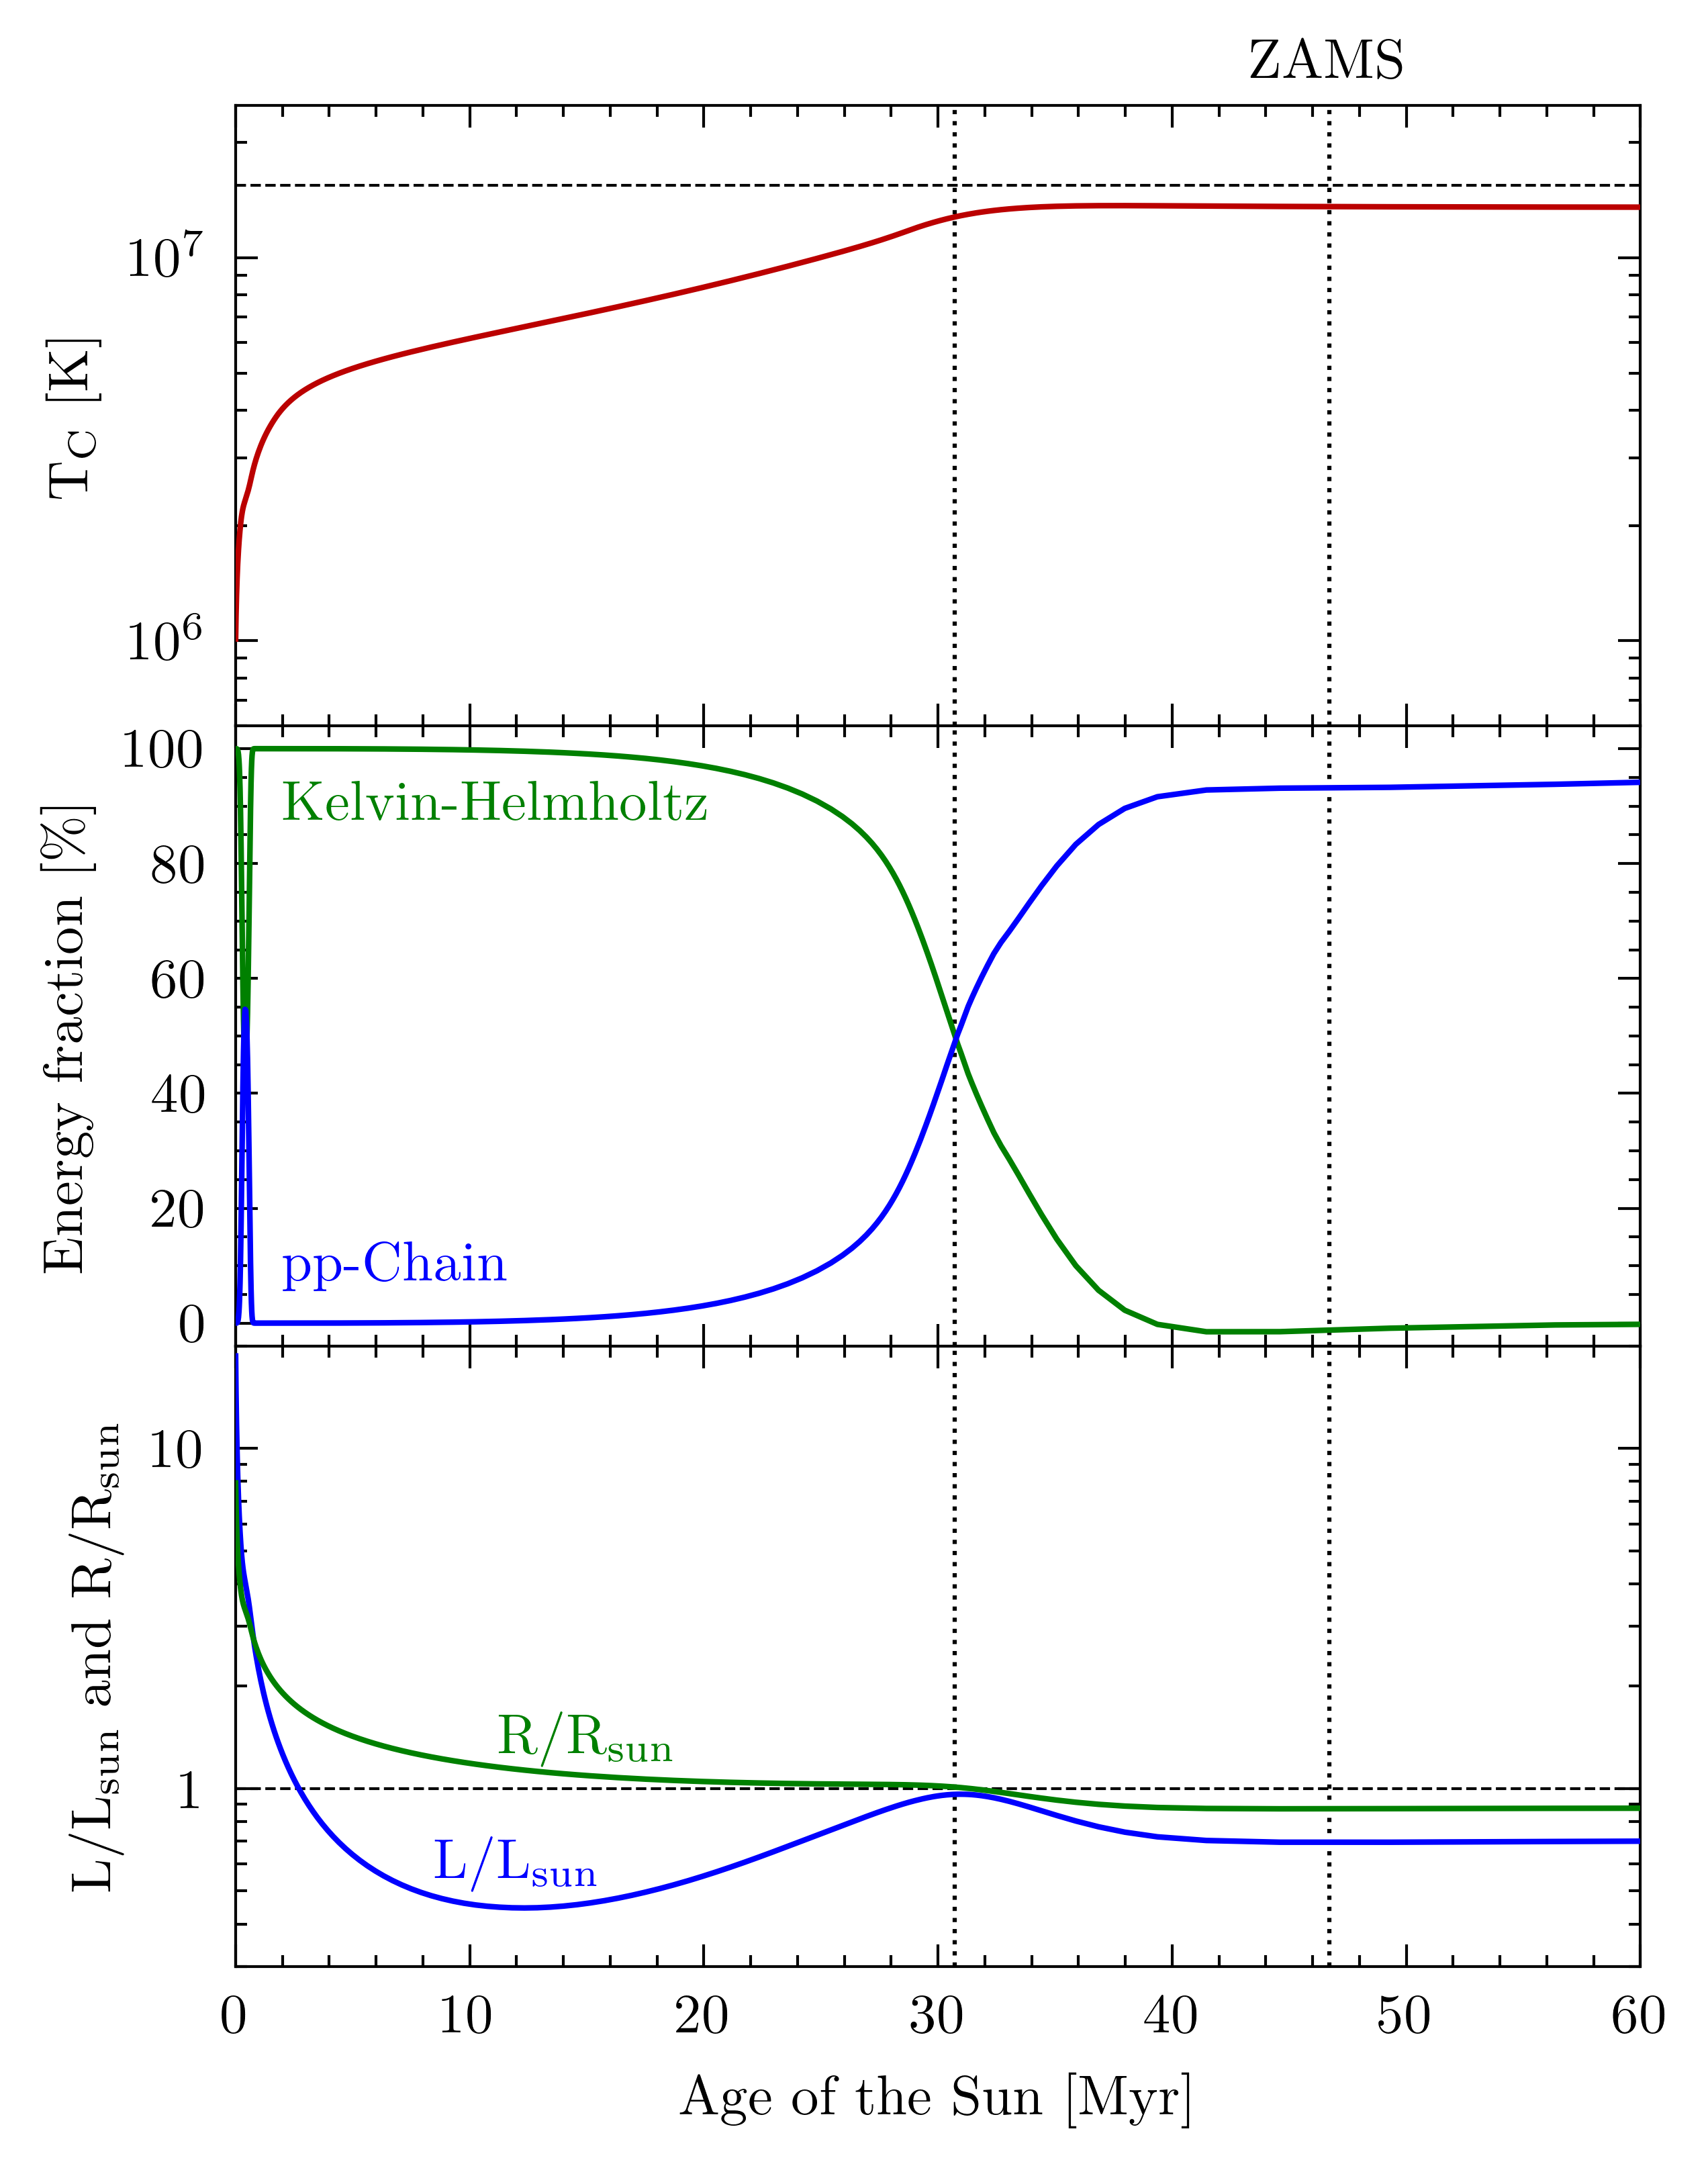

In [71]:
plotFile = 'sun_PMS_ZAMS.png'

# axis limits

ageMin = 0.0 
ageMax = 60.0 # Myr

tMin = 6.0e5 # K
tMax = 2.5e7 # K

efMin = -4  # %
efMax = 104 # %

# annotation parameters of interest

TCnow = 1.548e7 # present-day core temperature
age50 = 30.724 # time of 50/50 KH/fusion in Myr
ageZAMS= 46.7 # Zero-age Main Sequence in Myr

# do it

fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(hInches,wInches),dpi=dpi) # portrait!
fig.subplots_adjust(wspace=0, hspace=0.0)

# Top: core temperature evolution

ax1.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax1.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax1.set_xlim(ageMin,ageMax)
ax1.xaxis.set_major_locator(MultipleLocator(10.))
ax1.xaxis.set_minor_locator(MultipleLocator(2.))
ax1.set_xticklabels([])

ax1.set_ylim(tMin,tMax)
ax1.set_yscale('log')
ax1.set_ylabel(r'T$_{\rm C}$ [K]',fontsize=axisFontSize)

ax1.plot(ageEvo,1.0e6*coreT,ls='-',color="#bb0000",lw=1,zorder=10)

ax1.vlines([age50,ageZAMS],tMin,tMax,ls=[":"],colors=["black"],lw=0.75,zorder=8)
ax1.hlines(TCnow,ageMin,ageMax,ls=["--"],colors=["black"],lw=0.5,zorder=8)
ax1.text(ageZAMS,1.1*tMax,"ZAMS",va="bottom",ha="center",fontsize=axisFontSize,color="black")

# Middle: energy generation fraction evolution, K-H and pp-chain

ax2.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax2.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax2.set_xlim(ageMin,ageMax)
ax2.xaxis.set_major_locator(MultipleLocator(10.))
ax2.xaxis.set_minor_locator(MultipleLocator(2.))
ax2.set_xticklabels([])

ax2.set_ylim(efMin,efMax)
ax2.yaxis.set_major_locator(MultipleLocator(20.))
ax2.yaxis.set_minor_locator(MultipleLocator(5.))
ax2.set_ylabel(r'Energy fraction [\%]',fontsize=axisFontSize)

ax2.plot(ageEvo,100.0*eKH,ls='-',color="green",lw=1.0,zorder=10)
ax2.plot(ageEvo,100.0*ePP,ls='-',color="blue",lw=1.0,zorder=10)

ax2.vlines([age50,ageZAMS],efMin,efMax,ls=[":"],colors=["black"],lw=0.75,zorder=8)
ax2.text(2,90,"Kelvin-Helmholtz",va="center",ha="left",fontsize=axisFontSize,color="green")
ax2.text(2,10,"pp-Chain",va="center",ha="left",fontsize=axisFontSize,color="blue")

# Bottom: R/Rsun and L/Lsun evolution

ax3.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax3.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax3.set_xlim(ageMin,ageMax)
ax3.xaxis.set_major_locator(MultipleLocator(10.))
ax3.xaxis.set_minor_locator(MultipleLocator(2.))
ax3.set_xlabel(r'Age of the Sun [Myr]',fontsize=axisFontSize)

ax3.set_ylim(0.3,20)
ax3.set_yscale('log')
ax3.set_ylabel(r'L/L$_{\rm sun}$ and R/R$_{\rm sun}$',fontsize=axisFontSize)
ax3.set_yticks([1,10])
ax3.set_yticklabels(['1','10'])

ax3.plot(ageEvo,Lsun,ls='-',color="blue",lw=1,zorder=10)
ax3.plot(ageEvo,Rsun,ls='-',color="green",lw=1,zorder=10)

ax3.vlines([age50,ageZAMS],0.3,20.0,ls=[":"],colors=["black"],lw=0.75,zorder=8)
ax3.hlines(1.0,ageMin,ageMax,ls=["--"],colors=["black"],lw=0.5,zorder=8)

ax3.text(15,1.4,r"R/R$_{\rm sun}$",va="center",ha="center",fontsize=axisFontSize,color="green")
ax3.text(12,0.6,r"L/L$_{\rm sun}$",va="center",ha="center",fontsize=axisFontSize,color="blue")

# make the plot and hardcopy

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()

## Pre-main sequence and deuterium fusion

Evolution of core temperature, energy generation (pp vs K-H), radius, and luminosity from birth to 2Myr showing the brief period of deuterium fusion

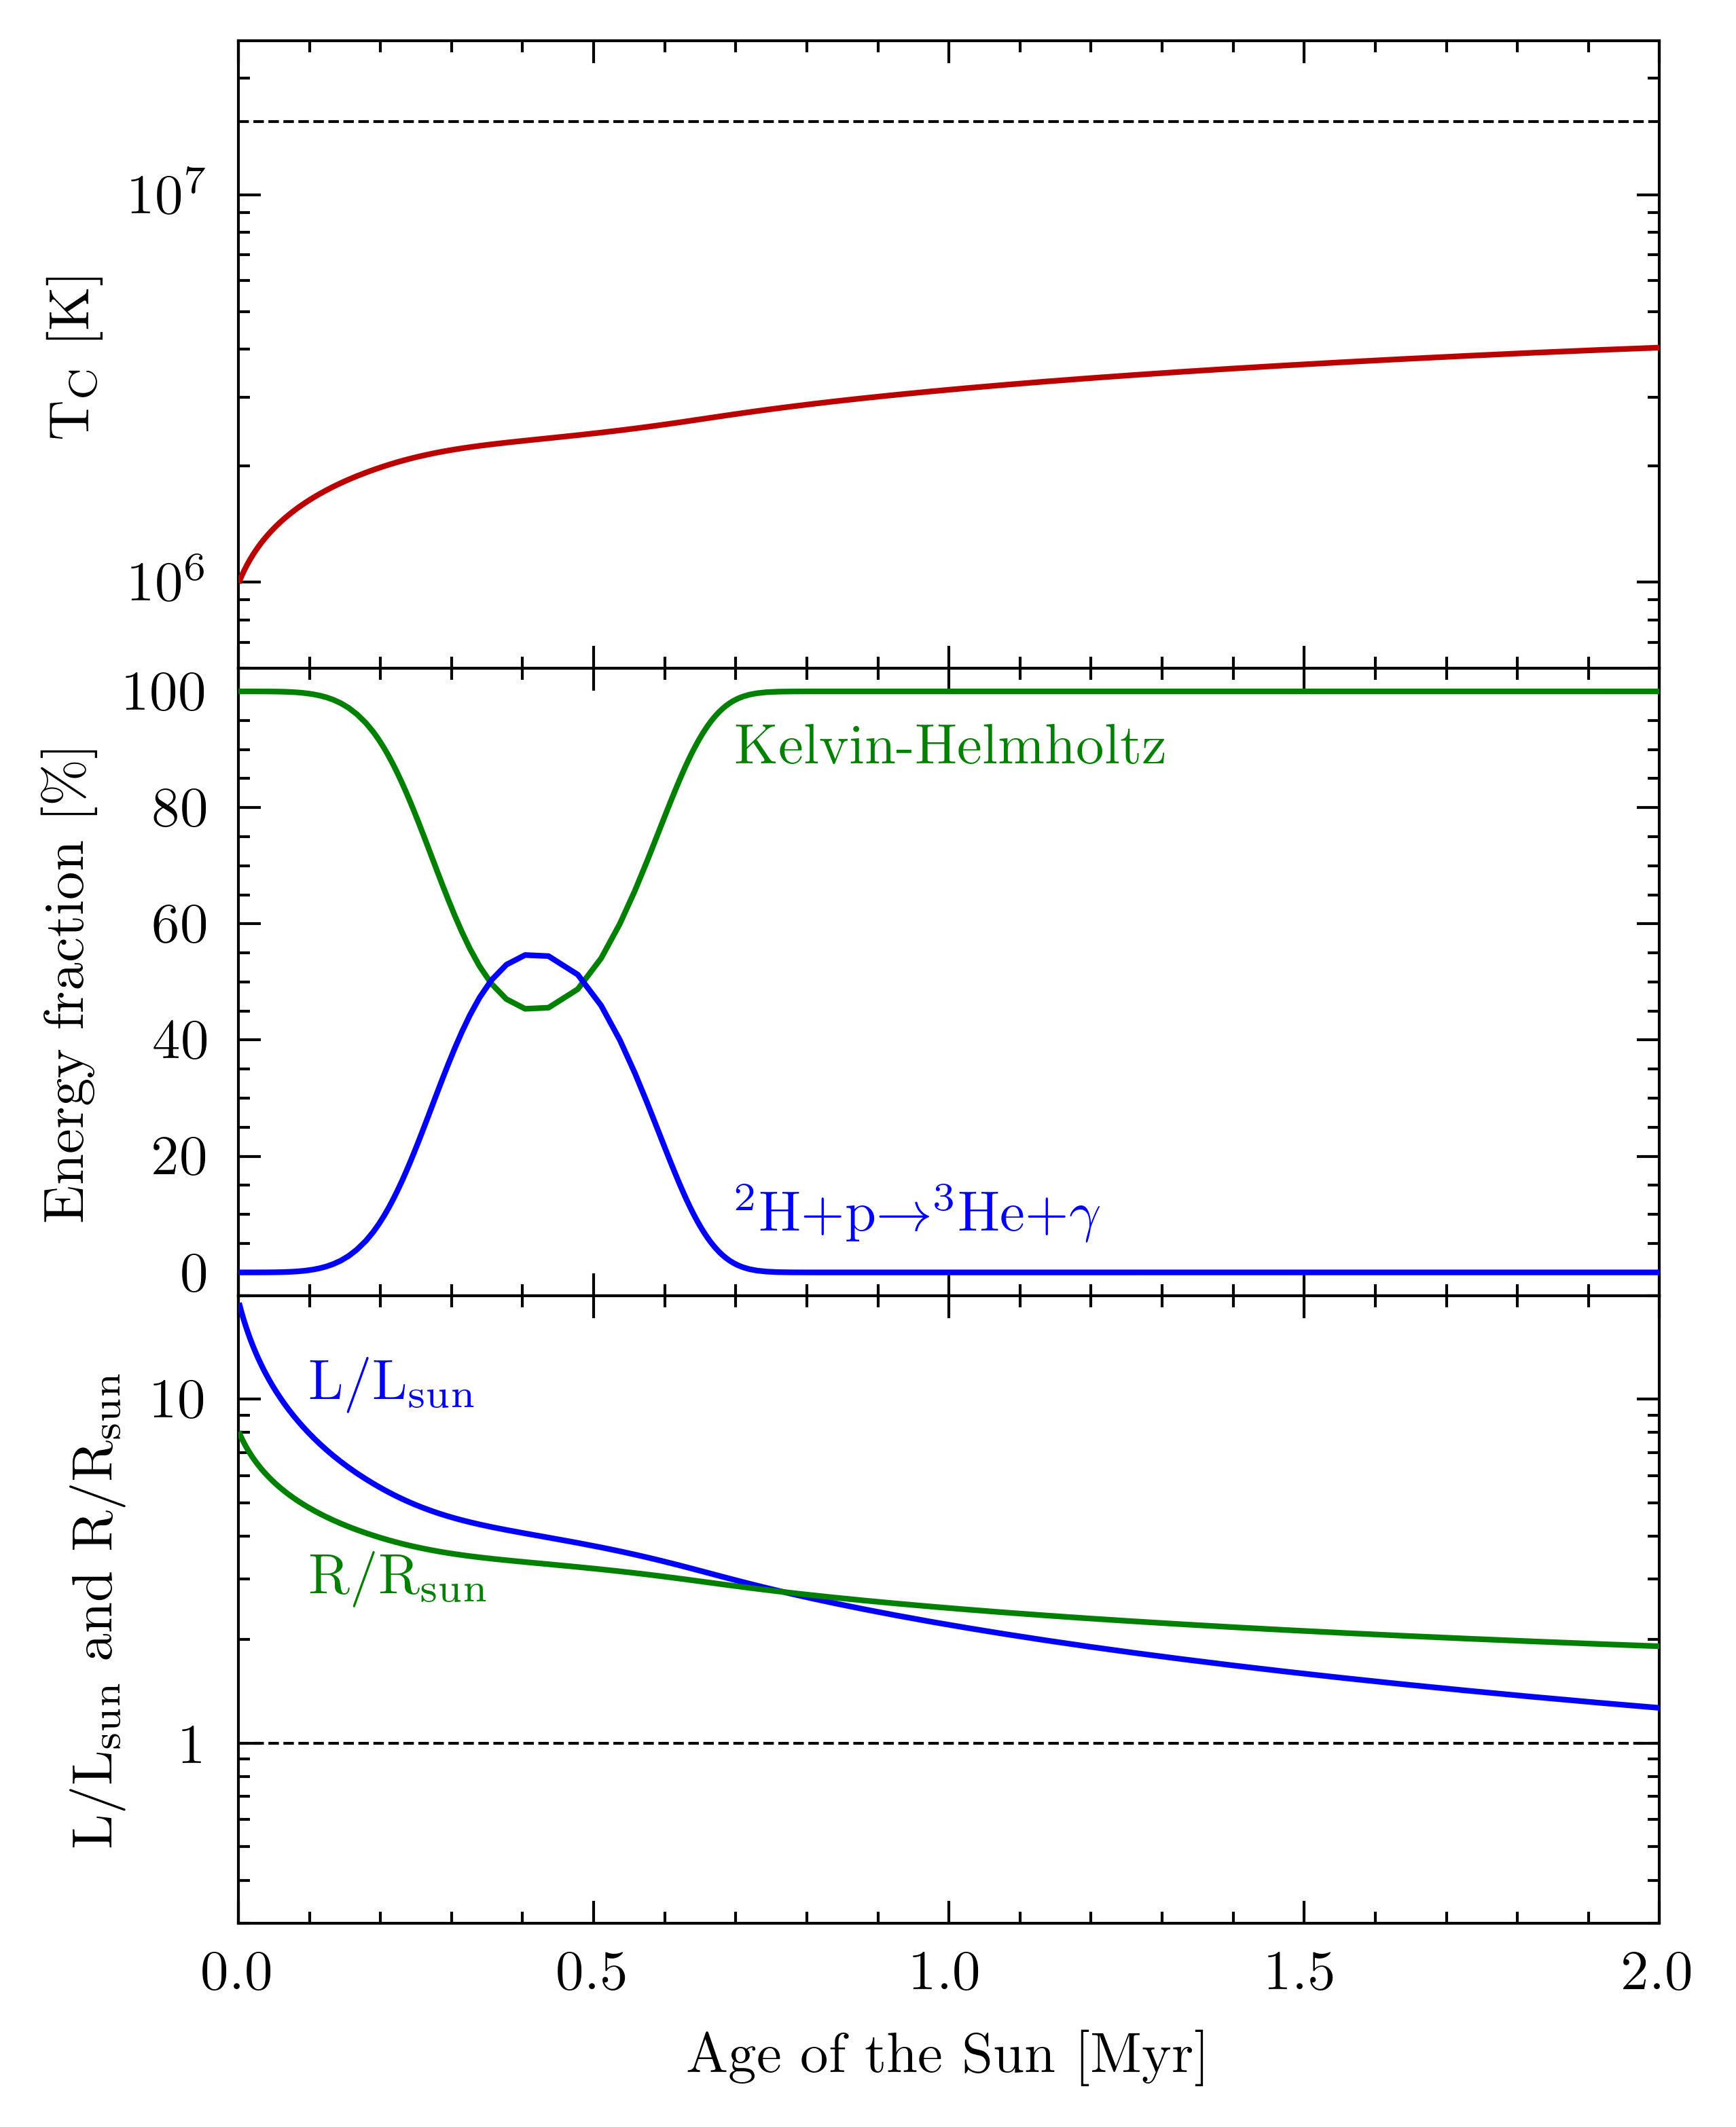

In [72]:
plotFile = 'sun_PMS_Dburn.png'

# axis limits

ageMin = 0.0 
ageMax = 2.0 # Myr

tMin = 6.0e5 # K
tMax = 2.5e7 # K

efMin = -4  # %
efMax = 104 # %

# annotation parameters of interest

TCnow = 1.548e7 # present-day core temperature
age50 = 30.724 # time of 50/50 KH/fusion in Myr
ageZAMS= 46.7 # Zero-age Main Sequence in Myr

# do it

fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(hInches,wInches),dpi=dpi) # portrait!
fig.subplots_adjust(wspace=0, hspace=0.0)

# Top: core temperature evolution

ax1.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax1.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax1.set_xlim(ageMin,ageMax)
ax1.xaxis.set_major_locator(MultipleLocator(0.5))
ax1.xaxis.set_minor_locator(MultipleLocator(0.1))
ax1.set_xticklabels([])

ax1.set_ylim(tMin,tMax)
ax1.set_yscale('log')
ax1.set_ylabel(r'T$_{\rm C}$ [K]',fontsize=axisFontSize)

ax1.plot(ageEvo,1.0e6*coreT,ls='-',color="#bb0000",lw=1,zorder=10)

ax1.hlines(TCnow,ageMin,ageMax,ls=["--"],colors=["black"],lw=0.5,zorder=8)

# Middle: energy generation fraction evolution, K-H and pp-chain

ax2.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax2.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax2.set_xlim(ageMin,ageMax)
ax2.xaxis.set_major_locator(MultipleLocator(0.5))
ax2.xaxis.set_minor_locator(MultipleLocator(0.1))
ax2.set_xticklabels([])

ax2.set_ylim(efMin,efMax)
ax2.yaxis.set_major_locator(MultipleLocator(20.))
ax2.yaxis.set_minor_locator(MultipleLocator(5.))
ax2.set_ylabel(r'Energy fraction [\%]',fontsize=axisFontSize)

ax2.plot(ageEvo,100.0*eKH,ls='-',color="green",lw=1.0,zorder=10)
ax2.plot(ageEvo,100.0*ePP,ls='-',color="blue",lw=1.0,zorder=10)

ax2.text(0.7,90,"Kelvin-Helmholtz",va="center",ha="left",fontsize=axisFontSize,color="green")
ax2.text(0.7,10,r"$^2$H+p$\rightarrow$$^3$He+$\gamma$",va="center",ha="left",fontsize=axisFontSize,color="blue")

# Bottom: R/Rsun and L/Lsun evolution

ax3.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax3.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax3.set_xlim(ageMin,ageMax)
ax3.xaxis.set_major_locator(MultipleLocator(0.5))
ax3.xaxis.set_minor_locator(MultipleLocator(0.1))
ax3.set_xlabel(r'Age of the Sun [Myr]',fontsize=axisFontSize)

ax3.set_ylim(0.3,20)
ax3.set_yscale('log')
ax3.set_ylabel(r'L/L$_{\rm sun}$ and R/R$_{\rm sun}$',fontsize=axisFontSize)
ax3.set_yticks([1,10])
ax3.set_yticklabels(['1','10'])

ax3.plot(ageEvo,Lsun,ls='-',color="blue",lw=1,zorder=10)
ax3.plot(ageEvo,Rsun,ls='-',color="green",lw=1,zorder=10)

ax3.hlines(1.0,ageMin,ageMax,ls=["--"],colors=["black"],lw=0.5,zorder=8)

ax3.text(0.1,3,r"R/R$_{\rm sun}$",va="center",ha="left",fontsize=axisFontSize,color="green")
ax3.text(0.1,11,r"L/L$_{\rm sun}$",va="center",ha="left",fontsize=axisFontSize,color="blue")

# make the plot and hardcopy

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()